# Idea:
- Remove records of leftover
- Each meal refers to top-K using cosine
- Add other meals within the menu on the same day
- Supplement holiday and exam info

In [1]:
%cd ../../../

/Users/hoangle/Projects/untangling-people/ylva


In [2]:
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import holidays
import seaborn as sns
import polars as pl
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

In [3]:
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'font.size': 8})

# Load dims and raw data

In [4]:
K = 2
CUTOFF_DATE = pl.lit("2024-09-01", dtype=pl.Date)

## dim `meals`

In [5]:
dim_meals = pl.read_parquet("data/processed/phase_4/dim_meals.parquet")
dim_meals.head()

meal_id,meal_type,schoolyear,restaurant,attributes,aliases
i64,str,str,list[str],list[str],list[str]
9017,"""vegan""","""24-25""","[""che"", ""exa"", ""vik""]","[""vegan-miscellaneous"", ""kela""]","[""""Butter"" härkäpapua & pähkinää""]"
7201,"""vegan""","""23-24""",null,[],"[""2023 Härkäpu-sienilasagnette""]"
9032,"""vegan""","""23-24""",null,[],"[""Appelisiini-luomukikhernecurrya""]"
9102,"""vegan""","""23-24""",null,[],"[""Artisokkavugetteja & tuoretomaattisalsaa""]"
7010,"""vegetarian""","""24-25""","[""che"", ""exa"", ""vik""]",[],"[""Aurajuusto-pinaattilasagnette"", ""Aurajuusto-pinaattilasagnettea""]"


## dim `meal_types`

In [6]:
dim_meal_types = (
    dim_meals.select('meal_id', 'meal_type')
)
dim_meal_types.head()

meal_id,meal_type
i64,str
9017,"""vegan"""
7201,"""vegan"""
9032,"""vegan"""
9102,"""vegan"""
7010,"""vegetarian"""


## dim `meal_names`

In [7]:
dim_meal_names = (
    dim_meals
    .select(
        'meal_id',
        pl.col('aliases').alias('meal')
    )
    .explode('meal')
)
dim_meal_names.head()

meal_id,meal
i64,str
9017,"""""Butter"" härkäpapua & pähkinää"""
7201,"""2023 Härkäpu-sienilasagnette"""
9032,"""Appelisiini-luomukikhernecurry…"
9102,"""Artisokkavugetteja & tuoretoma…"
7010,"""Aurajuusto-pinaattilasagnette"""


## dim `opentime`

In [8]:
dim_opentime = (
    pl
    .from_records([
        {'restaurant': 'che', 'time_open': '10:30', 'time_close': '15:00'},
        {'restaurant': 'exa', 'time_open': '11:00', 'time_close': '14:00'},
        {'restaurant': 'phy', 'time_open': '10:00', 'time_close': '15:00'},
        {'restaurant': 'vik', 'time_open': '10:30', 'time_close': '14:00'},
    ])
    .select(
        'restaurant',
        pl.col('time_open').str.to_datetime("%H:%M"),
        pl.col('time_close').str.to_datetime("%H:%M")
    )
    .with_columns(
        ((pl.col('time_close') - pl.col('time_open')).dt.total_minutes() / 60.).alias('working_duration')
    )
)

dim_opentime.head()

restaurant,time_open,time_close,working_duration
str,datetime[μs],datetime[μs],f64
"""che""",0001-01-01 10:30:00,0001-01-01 15:00:00,4.5
"""exa""",0001-01-01 11:00:00,0001-01-01 14:00:00,3.0
"""phy""",0001-01-01 10:00:00,0001-01-01 15:00:00,5.0
"""vik""",0001-01-01 10:30:00,0001-01-01 14:00:00,3.5


## dim `exam`

In [9]:
DATE_START = pl.lit('2023-01-02').str.to_date()
DATE_END = pl.lit('2024-10-31').str.to_date()

In [10]:
dim_exam_raw = (
    pl
    .from_records([
        {'date_begin': '2023-03-06', 'date_end': '2023-03-12'},  
        {'date_begin': '2023-05-01', 'date_end': '2023-05-07'},
        {'date_begin': '2023-10-23', 'date_end': '2023-10-29'},
        {'date_begin': '2023-12-18', 'date_end': '2023-12-24'},
        {'date_begin': '2024-03-04', 'date_end': '2024-03-10'},
        {'date_begin': '2024-05-06', 'date_end': '2024-05-12'},
        {'date_begin': '2024-10-21', 'date_end': '2024-10-27'},
    ])
    .with_columns(
        pl.col('date_begin').str.to_date(),
        pl.col('date_end').str.to_date(),
    )
)


df = (
    pl.DataFrame()

    # Create blank dataframe with date
    .with_columns(
        pl.date_range(DATE_START, DATE_END, '1d').alias('date')
    )
)

entries_exam = (
    df
    .join(dim_exam_raw, how='cross')
    .filter(
        (pl.col('date') >= pl.col('date_begin'))
        & (pl.col('date') <= pl.col('date_end'))
    )
    .select(
        'date',
        pl.lit(True).alias('is_exam')
    )
)
dim_exam = (
    df
    .join(entries_exam, on='date', how='left')
    .with_columns(pl.col('is_exam').fill_null(False).cast(pl.Int32))

    # Remove non-business days
    .filter(pl.col('date').dt.weekday() < 6)
)

dim_exam.head()

date,is_exam
date,i32
2023-01-02,0
2023-01-03,0
2023-01-04,0
2023-01-05,0
2023-01-06,0


## dim `holiday`

In [11]:
fin_holidays = holidays.Finland(years=[2023, 2024, 2025])
dim_holiday_raw = pl.from_records([
    {'date': d, 'name_holiday': n}
    for d, n in fin_holidays.items()
])


dim_holiday = (
    pl.DataFrame()

    # Create blank dataframe with date
    .with_columns(
        pl.date_range(DATE_START, DATE_END, '1d').alias('date')
    )


    # Add dim holiday
    .join(dim_holiday_raw, on='date', how='left')
    .with_columns(pl.col('name_holiday').is_not_null().cast(pl.Int32).alias('is_holiday'))
    .drop('name_holiday')

    # Remove non-business days
    .filter(pl.col('date').dt.weekday() < 6)
)

dim_holiday.head()

date,is_holiday
date,i32
2023-01-02,0
2023-01-03,0
2023-01-04,0
2023-01-05,0
2023-01-06,1


## raw POS

In [12]:
paths = [
    "data/raw/pos/Sold lunches.csv",
    "data/raw/pos/Sold lunches Kumpula 6-8 2024.csv",
    "data/raw/pos/Sold lunches Kumpula 9-10 2024.csv",
    "data/raw/pos/Sold lunches Viikuna 2023.csv",
    "data/raw/pos/Sold lunches Viikuna 2024.csv"
]

raw = []
for path in paths:
    df = pl.read_csv(path, separator=';', has_header=False, skip_rows=1)
    # df.columns = np.arange(df.shape[1], dtype=str)
    raw.append(df)


pos = pl.concat(raw)



# Rename columns
pos.columns = ['date', 'time', 'restaurant', 'meal_type', 'meal', 'pcs', 'co2']



# Convert pcs
pos = pos.filter((pl.col('pcs').is_not_null()) & (pl.col('pcs') >= 0))


# Map restaurant name
names_restaurant = {
    '600 Chemicum': 'che', #'chemicum',
    '610 Physicum': 'phy', #'physicum',
    '620 Exactum': 'exa', #'exactum'
    '570 Viikuna': 'vik',
}
pos = pos.with_columns(pl.col('restaurant').replace_strict(names_restaurant))


# Process date
pos = (
    pos
    .with_columns(
        (pl.col('date') + " " + pl.col('time')).str.to_datetime("%d.%m.%Y %H:%M").alias('datetime')
    )
    .drop('date', 'time')
)


# Process meal
pos = (
    pos

    # Remove trailing spaces
    .with_columns(
        pl.col('meal').str.strip_chars(' ')
    )

    
    # Get meal_id
    .join(dim_meal_names, on='meal', how='left')

    
    # Remove entries having no `meal_id`
    .filter(pl.col('meal_id').is_not_null())
)



# Aggregate by date and supplement serving duration per day
pos = (
    pos
    .group_by('restaurant', pl.col('datetime').dt.date().alias('date'), 'meal_id')
    .agg(
        pl.col('pcs').sum(),
        pl.col('datetime').min().alias('time_start'),
        pl.col('datetime').max().alias('time_end'),
    )
    .with_columns(
        ((pl.col('time_end') - pl.col('time_start')).dt.total_minutes() / 60.).alias('serving_duration')
    )
    .join(
        dim_opentime.select('restaurant', 'working_duration'),
        on='restaurant',
        how='left'
    )
    .with_columns(
        (pl.col('serving_duration') / pl.col('working_duration')).alias('serving_percent')
    )
)



# Remove redundant columns
pos = pos.drop('time_start', 'time_end', 'serving_duration', 'working_duration')


# Add meal_type
pos = (
    pos
    .join(
        dim_meals.select('meal_id', 'meal_type'),
        on='meal_id',
        how='left'
    )
)



# Ignore buffet
pos = pos.filter(pl.col('meal_type') != pl.lit('buffet'))




# Remove pos of leftover meals
pos = (
    pos
    .with_columns(
        pl.col('date').shift(1).over('restaurant', 'meal_id', order_by='date').alias('date_lag'),
        pl.col('pcs').shift(1).over('restaurant', 'meal_id', order_by='date').alias('pcs_lag'),
    )
    .filter(
        (pl.col('date_lag').is_null())
        | ((pl.col('date') - pl.col('date_lag')).dt.total_days() > 7)
    )
    .drop('date_lag', 'pcs_lag')
)


# Keep records whose POS value is greater than Q1 value
pos = (
    pos
    .with_columns(
        pl.col('pcs').quantile(.25).over('restaurant', 'meal_id', order_by='date').alias('pcs_q1')
    )
    .filter(pl.col('pcs') >= pl.col('pcs_q1'))
    .drop('pcs_q1')
)



# Keep records whose serving_percent is greater than THETA
THETA = .48         # this is the 1st quartile of raw data
pos = (
    pos
    .filter(pl.col('serving_percent') >= THETA)
    # .drop('serving_percent')
)


pos.head()


restaurant,date,meal_id,pcs,serving_percent,meal_type
str,date,i64,i64,f64,str
"""phy""",2024-10-21,1453,16,0.643333,"""fish"""
"""che""",2024-10-29,983,116,0.959259,"""vegan"""
"""che""",2023-10-26,90000004,277,1.051852,"""vegan"""
"""che""",2023-10-12,90000059,131,0.92963,"""chicken"""
"""che""",2024-06-04,90000143,222,0.859259,"""meat"""


In [13]:
pos_train = pos.filter(pl.col('date') < CUTOFF_DATE)

## dim `reference`

In [14]:
# dim_meal_embds = pl.read_parquet("data/inter/meal_names_embds.parquet")
# dim_meal_embds = pl.read_parquet("data/processed/embedding_tuning/meal_embds_02-27_12-04-54.parquet")
dim_meal_embds = pl.read_parquet("data/processed/embedding_tuning/meal_embds_02-27_14-52-58.parquet")

embds_1 = np.vstack(dim_meal_embds.get_column('embedding_encoded').to_numpy())
dist = 1 - (embds_1 @ embds_1.T).flatten()

dim_dist = dim_meal_embds.select('meal_id')
dim_dist = dim_dist.join(dim_dist, how='cross')

# Add distance
dim_dist = dim_dist.with_columns(pl.Series(dist).alias('dist'))
dim_dist.head()

meal_id,meal_id_right,dist
i64,i64,f32
790,790,0.0
790,90000027,1.308276
790,6940,1.382586
790,6142,1.088635
790,916,1.051984


In [15]:
dim_reference = (
    dim_meals

    .select('meal_id', 'meal_type', 'restaurant')

    # Remove null records
    .drop_nulls()

    # Expand
    .explode('restaurant')
)


dim_reference = (
    dim_reference
    .join(dim_reference, how='cross')


    # Only keep records having different meal id
    .filter(pl.col('meal_id') != pl.col('meal_id_right'))

    # Only keep records having same meal_type and restaurant
    .filter(
        (pl.col('meal_type') == pl.col('meal_type_right'))
        & ((pl.col('restaurant') == pl.col('restaurant_right')))
    )

    # Add distance for each record
    .join(
        dim_dist,
        on=['meal_id', 'meal_id_right'],
        how='left'
    )
)




# Only keep references whose the targets already appear in train set

pcs_median = (
    pos_train
    .group_by('restaurant', 'meal_type', 'meal_id')
    .agg(pl.col('pcs').mean().alias('pcs_median'))

    .rename({
        'restaurant': 'restaurant_right',
        'meal_type': 'meal_type_right',
        'meal_id': 'meal_id_right',
    })
)
dim_reference = (
    dim_reference   
    .join(
        pcs_median,
        on=['restaurant_right', 'meal_type_right', 'meal_id_right'],
        how='inner'
    )
)



# For each meal, only keep K
dim_reference = (
    dim_reference   
    .with_columns(
        pl.col('dist').rank(descending=False).over('meal_id', 'restaurant', 'meal_type').alias('rank')
    )
    .filter(pl.col('rank') <= K)
    
    .select(
        pl.col('restaurant'),
        pl.col('meal_id').alias('meal'),
        pl.col('meal_id_right').alias('meal_ref'),
        'dist', 'pcs_median',
    )
)



dim_reference.head()

restaurant,meal,meal_ref,dist,pcs_median
str,i64,i64,f32,f64
"""che""",9017,7206,0.263165,178.0
"""che""",9017,90000146,0.269333,185.0
"""exa""",9017,90000127,0.231816,68.0
"""exa""",9017,90000147,0.28131,134.7
"""vik""",9017,90000146,0.269333,144.333333


## dim `coexist`

In [16]:
topN_restaurant = pl.from_dicts([
    {'restaurant': 'che', 'topN': 3},
    {'restaurant': 'vik', 'topN': 3},
    {'restaurant': 'exa', 'topN': 3},
    {'restaurant': 'phy', 'topN': 3},
])

dim_coexist = (
    pos

    .join(topN_restaurant, on='restaurant')


    # .filter(
    #     (pl.col('restaurant') == pl.lit("vik"))
    #     & (pl.col('date') == pl.lit('2023-05-24').str.to_date())
    # )


    .with_columns(
        pl.col('pcs').rank(descending=True, method='ordinal').over('restaurant', 'date').alias('rank')
    )
    .filter(
        pl.col('rank') <= pl.col('topN')
    )

    .select('restaurant', 'date', 'meal_id')
)


meals_coexist = (
    dim_coexist
    .group_by('restaurant', 'date')
    .agg(
        pl.concat_list('meal_id').flatten().alias('meals_coexist')
    )
)
dim_coexist = (
    dim_coexist

    .join(meals_coexist, on=['restaurant', 'date'])
    .with_columns(
        pl.col('meals_coexist').list.sample(fraction=1, shuffle=True)
    )
    .explode('meals_coexist')
    .filter(pl.col('meal_id') != pl.col('meals_coexist'))
    .with_columns(
        pl.format(
            "coexist_{}", 
            pl.int_range(pl.len()).over('restaurant', 'date', 'meal_id')
        ).alias('coexist'),
    )
    .pivot(
        on='coexist',
        index=['restaurant', 'date', 'meal_id'],
        values='meals_coexist'
    )

    # .filter(pl.any_horizontal(pl.all().is_null()))
)

dim_coexist.head()

restaurant,date,meal_id,coexist_0,coexist_1
str,date,i64,i64,i64
"""che""",2024-10-29,983,90000113,7560
"""che""",2023-10-26,90000004,6156,7607
"""che""",2023-10-12,90000059,90000123,90000151
"""che""",2024-06-04,90000143,7612,90000081
"""che""",2023-10-16,90000068,726,7582


## Add more features to fact table

In [17]:
# Add holiday
pos = (
    pos
    .join(dim_holiday, on='date', how='left')
)


# Add exam
pos = (
    pos
    .join(dim_exam, on='date', how='left')
)



# Add coexist
pos = (
    pos
    .join(dim_coexist, on=['restaurant', 'date', 'meal_id'], how='left')


    # Add meal_type for coexist meals
    .join(
        dim_meal_types.rename({'meal_id': 'coexist_0', 'meal_type': 'coexist_0_meal_type'}),
        on='coexist_0',
        how='left',
    )

    .join(
        dim_meal_types.rename({'meal_id': 'coexist_1', 'meal_type': 'coexist_1_meal_type'}),
        on='coexist_1',
        how='left',
    )
)


# Add reference of 
pos = (
    pos
    # Add reference for main meal
    .join(dim_reference, left_on=['meal_id', 'restaurant'], right_on=['meal', 'restaurant'], how='left')
    .rename({
        'meal_ref': 'main_meal_ref',
        'dist': 'main_dist_ref',
        'pcs_median': 'main_pcs_med_ref',
    })
    .filter(pl.col('main_meal_ref').is_not_null())


    # Add reference for coexist_0 meal
    .rename({'coexist_0': 'meal'})
    .join(dim_reference, on=['meal', 'restaurant'], how='left')
    .rename({
        'meal_ref': 'coexist_0_meal_ref',
        'dist': 'coexist_0_dist_ref',
        'pcs_median': 'coexist_0_pcs_med_ref',
    })
    .drop('meal')


    # Add reference for coexist_1 meal
    .rename({'coexist_1': 'meal'})
    .join(dim_reference, on=['meal', 'restaurant'], how='left')
    .rename({
        'meal_ref': 'coexist_1_meal_ref',
        'dist': 'coexist_1_dist_ref',
        'pcs_median': 'coexist_1_pcs_med_ref',
    })
    .drop('meal')



    # Fill null
    .with_columns(
        pl.col('coexist_0_meal_ref').fill_null(0),
        pl.col('coexist_0_dist_ref').fill_null(-1),
        pl.col('coexist_0_pcs_med_ref').fill_null(0),

        pl.col('coexist_1_meal_ref').fill_null(0),
        pl.col('coexist_1_dist_ref').fill_null(-1),
        pl.col('coexist_1_pcs_med_ref').fill_null(0),
        
    )
)

# Add flag to track records are of old/new meals
meals_old = pos_train.select(pl.col('meal_id').unique()).with_columns(pl.lit(False).alias('is_new'))
pos = pos.join(meals_old, on='meal_id', how='left').with_columns(pl.col('is_new').fill_null(True))


pos.head()

restaurant,date,meal_id,pcs,serving_percent,meal_type,is_holiday,is_exam,coexist_0_meal_type,coexist_1_meal_type,main_meal_ref,main_dist_ref,main_pcs_med_ref,coexist_0_meal_ref,coexist_0_dist_ref,coexist_0_pcs_med_ref,coexist_1_meal_ref,coexist_1_dist_ref,coexist_1_pcs_med_ref,is_new
str,date,i64,i64,f64,str,i32,i32,str,str,i64,f32,f64,i64,f32,f64,i64,f32,f64,bool
"""phy""",2024-10-21,1453,16,0.643333,"""fish""",0,1,null,null,1451,0.406516,23.5,0,-1.0,0.0,0,-1.0,0.0,false
"""phy""",2024-10-21,1453,16,0.643333,"""fish""",0,1,null,null,916,0.238452,12.222222,0,-1.0,0.0,0,-1.0,0.0,false
"""che""",2024-10-29,983,116,0.959259,"""vegan""",0,0,"""fish""","""vegan""",7203,0.300604,148.0,90000038,0.1781,319.166667,90000146,0.203958,185.0,false
"""che""",2024-10-29,983,116,0.959259,"""vegan""",0,0,"""fish""","""vegan""",7203,0.300604,148.0,90000038,0.1781,319.166667,90000147,0.152266,242.090909,false
"""che""",2024-10-29,983,116,0.959259,"""vegan""",0,0,"""fish""","""vegan""",7203,0.300604,148.0,90000123,0.165301,266.555556,90000146,0.203958,185.0,false


## Encode

In [18]:
# Encode restaurant
map_restaurant2id = {
    "phy": '0',
    "che": '1',
    "exa": '2',
    "vik": '3',
}
pos = pos.with_columns(pl.col('restaurant').replace(map_restaurant2id).cast(pl.Int32))


# Encode meal_type
map_mealtype2id = {
    "meat"        : 1,
    "vegetarian"  : 2,
    "chicken"     : 3,
    "fish"        : 4,
    "vegan"       : 5,
}
pos = (
    pos
    .with_columns(
        pl.col('meal_type').replace(map_mealtype2id).cast(pl.Int32),
        pl.col('coexist_1_meal_type').replace(map_mealtype2id).fill_null(0).cast(pl.Int32),
        pl.col('coexist_0_meal_type').replace(map_mealtype2id).fill_null(0).cast(pl.Int32),
    )
)

# Encode datetime
pos = (
    pos
    .with_columns(
        pl.col('date').dt.weekday().alias('weekday'),
        pl.col('date').dt.day().alias('day'),
        pl.col('date').dt.month().alias('month'),
    )
    .with_columns(
        (pl.col('weekday') * 2 * np.pi / 5).sin().alias('weekday_sin'),
        (pl.col('weekday') * 2 * np.pi / 5).cos().alias('weekday_cos'),
        (pl.col('day') * 2 * np.pi / 31).sin().alias('day_sin'),
        (pl.col('day') * 2 * np.pi / 31).cos().alias('day_cos'),
        (pl.col('month') * 2 * np.pi / 12).sin().alias('month_sin'),
        (pl.col('month') * 2 * np.pi / 12).cos().alias('month_cos'),
    )
    .drop('weekday', 'day', 'month')
)


pos.head()

restaurant,date,meal_id,pcs,serving_percent,meal_type,is_holiday,is_exam,coexist_0_meal_type,coexist_1_meal_type,main_meal_ref,main_dist_ref,main_pcs_med_ref,coexist_0_meal_ref,coexist_0_dist_ref,coexist_0_pcs_med_ref,coexist_1_meal_ref,coexist_1_dist_ref,coexist_1_pcs_med_ref,is_new,weekday_sin,weekday_cos,day_sin,day_cos,month_sin,month_cos
i32,date,i64,i64,f64,i32,i32,i32,i32,i32,i64,f32,f64,i64,f32,f64,i64,f32,f64,bool,f64,f64,f64,f64,f64,f64
0,2024-10-21,1453,16,0.643333,4,0,1,0,0,1451,0.406516,23.5,0,-1.0,0.0,0,-1.0,0.0,false,0.951057,0.309017,-0.897805,-0.440394,-0.866025,0.5
0,2024-10-21,1453,16,0.643333,4,0,1,0,0,916,0.238452,12.222222,0,-1.0,0.0,0,-1.0,0.0,false,0.951057,0.309017,-0.897805,-0.440394,-0.866025,0.5
1,2024-10-29,983,116,0.959259,5,0,0,4,5,7203,0.300604,148.0,90000038,0.1781,319.166667,90000146,0.203958,185.0,false,0.587785,-0.809017,-0.394356,0.918958,-0.866025,0.5
1,2024-10-29,983,116,0.959259,5,0,0,4,5,7203,0.300604,148.0,90000038,0.1781,319.166667,90000147,0.152266,242.090909,false,0.587785,-0.809017,-0.394356,0.918958,-0.866025,0.5
1,2024-10-29,983,116,0.959259,5,0,0,4,5,7203,0.300604,148.0,90000123,0.165301,266.555556,90000146,0.203958,185.0,false,0.587785,-0.809017,-0.394356,0.918958,-0.866025,0.5


# Train

In [19]:
cols_X = [
    'restaurant',
    'meal_type',
    'is_holiday',
    'is_exam',
    'coexist_0_meal_type',
    'coexist_1_meal_type',

    'main_meal_ref',
    'main_dist_ref',
    'main_pcs_med_ref',

    'coexist_0_meal_ref',
    'coexist_0_dist_ref',
    'coexist_0_pcs_med_ref',

    'coexist_1_meal_ref',
    'coexist_1_dist_ref',
    'coexist_1_pcs_med_ref',

    'serving_percent',
    'weekday_sin',
    'weekday_cos',
    'day_sin',
    'day_cos',
    'month_sin',
    'month_cos'
]
col_y = 'pcs'
cols_cat = [
    'restaurant',
    'meal_type',
    'is_holiday',
    'is_exam',
    'coexist_0_meal_type',
    'coexist_1_meal_type',
    'main_meal_ref',
    'coexist_0_meal_ref',
    'coexist_1_meal_ref'
]


pos_train = pos.filter(pl.col('date') < CUTOFF_DATE)
pos_val = pos.filter(pl.col('date') >= CUTOFF_DATE)

Xtrain, ytrain = pos_train.select(cols_X).to_pandas(), pos_train.get_column(col_y).to_pandas()
Xval, yval = pos_val.select(cols_X).to_pandas(), pos_val.get_column(col_y).to_pandas()

pos_train.head()

restaurant,date,meal_id,pcs,serving_percent,meal_type,is_holiday,is_exam,coexist_0_meal_type,coexist_1_meal_type,main_meal_ref,main_dist_ref,main_pcs_med_ref,coexist_0_meal_ref,coexist_0_dist_ref,coexist_0_pcs_med_ref,coexist_1_meal_ref,coexist_1_dist_ref,coexist_1_pcs_med_ref,is_new,weekday_sin,weekday_cos,day_sin,day_cos,month_sin,month_cos
i32,date,i64,i64,f64,i32,i32,i32,i32,i32,i64,f32,f64,i64,f32,f64,i64,f32,f64,bool,f64,f64,f64,f64,f64,f64
1,2023-10-26,90000004,277,1.051852,5,0,1,4,3,1312,0.200947,186.0,8987,0.443483,219.0,1289,0.277773,346.8,false,-0.951057,0.309017,-0.848644,0.528964,-0.866025,0.5
1,2023-10-26,90000004,277,1.051852,5,0,1,4,3,1312,0.200947,186.0,8987,0.443483,219.0,90000007,0.28,85.0,false,-0.951057,0.309017,-0.848644,0.528964,-0.866025,0.5
1,2023-10-26,90000004,277,1.051852,5,0,1,4,3,1312,0.200947,186.0,901,0.504693,141.0,1289,0.277773,346.8,false,-0.951057,0.309017,-0.848644,0.528964,-0.866025,0.5
1,2023-10-26,90000004,277,1.051852,5,0,1,4,3,1312,0.200947,186.0,901,0.504693,141.0,90000007,0.28,85.0,false,-0.951057,0.309017,-0.848644,0.528964,-0.866025,0.5
1,2023-10-26,90000004,277,1.051852,5,0,1,4,3,90000147,0.213763,242.090909,8987,0.443483,219.0,1289,0.277773,346.8,false,-0.951057,0.309017,-0.848644,0.528964,-0.866025,0.5


In [20]:
models = {
    # 'HistGB':   {'model': HistGradientBoostingRegressor(categorical_features=cols_cat), 'is_cat': True},
    'XGB-cat':  {'model': XGBRegressor(tree_method="hist", enable_categorical=True), 'is_cat': True},
    'CatBoost': {'model': CatBoostRegressor(verbose=False, cat_features=cols_cat), 'is_cat': True},
    'LBGM-cat': {'model': LGBMRegressor(verbose=0, num_leaves=100), 'is_cat': True},

    'RF':       {'model': RandomForestRegressor(n_jobs=-1), 'is_cat': False},
    'LBGM':     {'model': LGBMRegressor(verbose=0), 'is_cat': False},
    'XGB':      {'model': XGBRegressor(), 'is_cat': False},
}

for name, model in models.items():
    print(f"Start: {name}")

    X = Xtrain.copy()

    if model['is_cat'] is True:
        for col in cols_cat:
            X[col] = X[col].astype('category')

    if name == 'LBGM-cat':
        kwargs = dict(categorical_feature=cols_cat)
    else:
        kwargs = {}
    model['model'].fit(X, ytrain, **kwargs)

Start: XGB-cat
Start: CatBoost
Start: LBGM-cat
Start: RF
Start: LBGM
Start: XGB


== Split: val
Start: XGB-cat
rmse: 83.8086
mae : 63.6120
Start: CatBoost
rmse: 57.3468
mae : 44.9287
Start: LBGM-cat
rmse: 59.3559
mae : 45.4875
Start: RF
rmse: 63.8867
mae : 50.5233
Start: LBGM
rmse: 59.5565
mae : 46.3887
Start: XGB
rmse: 61.1786
mae : 47.7223
== Split: train
Start: XGB-cat
rmse: 4.8677
mae : 2.5781
Start: CatBoost
rmse: 18.3471
mae : 13.3596
Start: LBGM-cat
rmse: 11.1141
mae : 7.9749
Start: RF
rmse: 4.5377
mae : 2.5312
Start: LBGM
rmse: 26.5664
mae : 19.8205
Start: XGB
rmse: 11.2913
mae : 7.9949


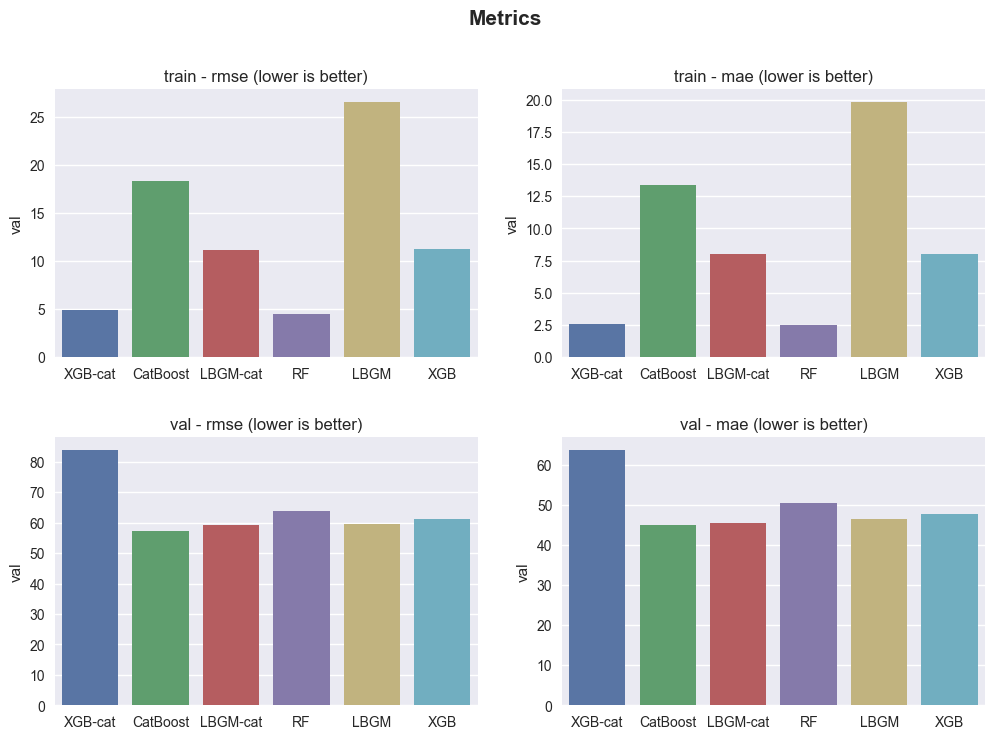

In [21]:
metrics_models = []

def calc_metrics(split: pl.DataFrame, model: dict, verbose: bool = False) -> tuple:
    split = split.clone()

    X = split.select(cols_X).to_pandas()
    

    if model['is_cat'] is True:
        for col in cols_cat:
            X[col] = X[col].astype('category')

    pcs_pred = np.clip(model['model'].predict(X), a_min=0, a_max=None)
    split = split.with_columns(pl.Series(pcs_pred).alias('pcs_pred'))
    
    split = (
        split
        .group_by(['date', 'restaurant', 'meal_id', 'meal_type'])
        .agg(
            pl.col('pcs').mean(),
            pl.col('pcs_pred').mean(),
        )
    )
    tgt = split.get_column('pcs').to_pandas()
    pred = split.get_column('pcs_pred').to_pandas()
    
    
    rmse = root_mean_squared_error(tgt, pred)
    mae = mean_absolute_error(tgt, pred)

    if verbose is True:
        print(f"rmse: {rmse:.4f}")
        print(f"mae : {mae:.4f}")

    return rmse, mae

print("== Split: val")
for name, model in models.items():
    print(f"Start: {name}")

    rmse, mae = calc_metrics(pos_val, model, verbose=True)
    metrics_models.append({'model': name, 'val': rmse, 'split': 'val', 'metric': 'rmse'})
    metrics_models.append({'model': name, 'val': mae, 'split': 'val', 'metric': 'mae'})


print("== Split: train")
for name, model in models.items():
    print(f"Start: {name}")

    rmse, mae = calc_metrics(pos_train, model, verbose=True)
    metrics_models.append({'model': name, 'val': rmse, 'split': 'train', 'metric': 'rmse'})
    metrics_models.append({'model': name, 'val': mae, 'split': 'train', 'metric': 'mae'})



# Visualize
metrics = pd.DataFrame.from_records(metrics_models)

fig = plt.figure(figsize=(12, 8))
fig.suptitle("Metrics", fontsize=15, fontweight='bold')
fig.subplots_adjust(wspace=0.2, hspace=0.3)

for i, (split, metric) in enumerate(product(['train', 'val'], ['rmse', 'mae'])):
    df = metrics[(metrics['split'] == split) & (metrics['metric'] == metric)]

    ax = fig.add_subplot(2, 2, i+1)
    sns.barplot(df, x='model', y='val', ax=ax, hue='model')
    ax.set_title(f"{split} - {metric} (lower is better)")
    ax.set_xlabel("")


<Axes: xlabel='importance', ylabel='name'>

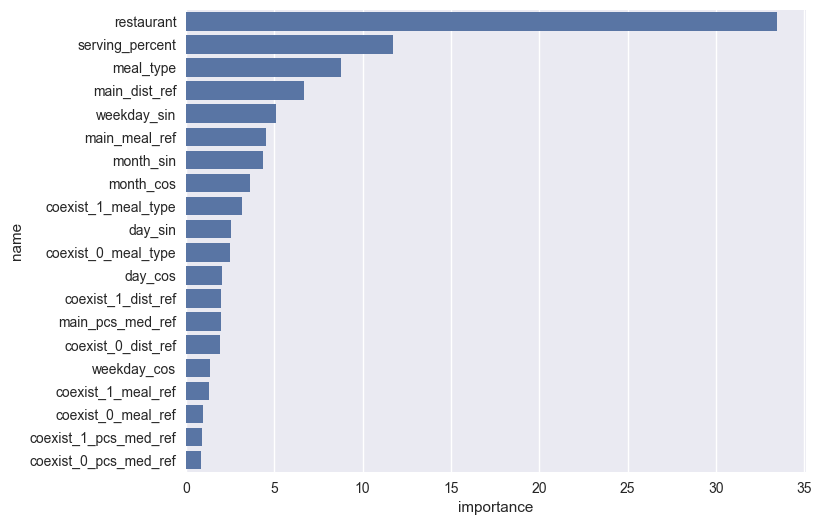

In [22]:
feat_imp = pd.DataFrame({
    'name': Xtrain.columns,
    'importance': models['CatBoost']['model'].feature_importances_
})

feat_imp.sort_values(by='importance', ascending=False, inplace=True)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
sns.barplot(feat_imp[:20], y='name', x='importance', ax=ax)

## Separately analyze results of old and new meals

In [23]:
model = models['CatBoost']

In [24]:
split = pos_val.clone()

X = split.select(cols_X).to_pandas()
tgt = split.get_column(col_y).to_pandas()

if model['is_cat'] is True:
    for col in cols_cat:
        X[col] = X[col].astype('category')

pcs_pred = np.clip(model['model'].predict(X), a_min=0, a_max=None)
split = split.with_columns(pl.Series(pcs_pred).alias('pcs_pred'))

split.head()

restaurant,date,meal_id,pcs,serving_percent,meal_type,is_holiday,is_exam,coexist_0_meal_type,coexist_1_meal_type,main_meal_ref,main_dist_ref,main_pcs_med_ref,coexist_0_meal_ref,coexist_0_dist_ref,coexist_0_pcs_med_ref,coexist_1_meal_ref,coexist_1_dist_ref,coexist_1_pcs_med_ref,is_new,weekday_sin,weekday_cos,day_sin,day_cos,month_sin,month_cos,pcs_pred
i32,date,i64,i64,f64,i32,i32,i32,i32,i32,i64,f32,f64,i64,f32,f64,i64,f32,f64,bool,f64,f64,f64,f64,f64,f64,f64
0,2024-10-21,1453,16,0.643333,4,0,1,0,0,1451,0.406516,23.5,0,-1.0,0.0,0,-1.0,0.0,false,0.951057,0.309017,-0.897805,-0.440394,-0.866025,0.5,12.942686
0,2024-10-21,1453,16,0.643333,4,0,1,0,0,916,0.238452,12.222222,0,-1.0,0.0,0,-1.0,0.0,false,0.951057,0.309017,-0.897805,-0.440394,-0.866025,0.5,12.651348
1,2024-10-29,983,116,0.959259,5,0,0,4,5,7203,0.300604,148.0,90000038,0.1781,319.166667,90000146,0.203958,185.0,false,0.587785,-0.809017,-0.394356,0.918958,-0.866025,0.5,181.292496
1,2024-10-29,983,116,0.959259,5,0,0,4,5,7203,0.300604,148.0,90000038,0.1781,319.166667,90000147,0.152266,242.090909,false,0.587785,-0.809017,-0.394356,0.918958,-0.866025,0.5,172.102704
1,2024-10-29,983,116,0.959259,5,0,0,4,5,7203,0.300604,148.0,90000123,0.165301,266.555556,90000146,0.203958,185.0,false,0.587785,-0.809017,-0.394356,0.918958,-0.866025,0.5,183.670566


In [25]:
split = pos_val.clone()

X = split.select(cols_X).to_pandas()
tgt = split.get_column(col_y).to_pandas()

if model['is_cat'] is True:
    for col in cols_cat:
        X[col] = X[col].astype('category')

pcs_pred = np.clip(model['model'].predict(X), a_min=0, a_max=None)
split = split.with_columns(pl.Series(pcs_pred).alias('pcs_pred'))
    
split = (
    split
    .group_by(['date', 'restaurant', 'meal_id', 'meal_type', 'is_new'])
    .agg(
        pl.col('pcs').mean(),
        pl.col('pcs_pred').mean(),
    )
)

split.head()

date,restaurant,meal_id,meal_type,is_new,pcs,pcs_pred
date,i32,i64,i32,bool,f64,f64
2024-09-12,1,7608,1,false,96.0,179.928009
2024-09-26,1,90000130,4,false,288.0,215.358131
2024-09-17,1,90000131,5,true,87.0,271.593534
2024-09-05,2,1021,5,false,120.0,95.579513
2024-09-11,2,880,4,false,114.0,104.436953


In [26]:
(
    pos_val
    .filter(
        (
            (1 == 1)
            # (pl.col('datetime').dt.date() == pl.lit('2023-02-28').str.to_date())
            & (pl.col('date') == pl.lit('2024-10-16').str.to_date())
            & (pl.col('meal_id') == 90000131)
        )
        & (pl.col('restaurant') == 1)
    )
)

restaurant,date,meal_id,pcs,serving_percent,meal_type,is_holiday,is_exam,coexist_0_meal_type,coexist_1_meal_type,main_meal_ref,main_dist_ref,main_pcs_med_ref,coexist_0_meal_ref,coexist_0_dist_ref,coexist_0_pcs_med_ref,coexist_1_meal_ref,coexist_1_dist_ref,coexist_1_pcs_med_ref,is_new,weekday_sin,weekday_cos,day_sin,day_cos,month_sin,month_cos
i32,date,i64,i64,f64,i32,i32,i32,i32,i32,i64,f32,f64,i64,f32,f64,i64,f32,f64,bool,f64,f64,f64,f64,f64,f64
1,2024-10-16,90000131,24,0.807407,5,0,0,4,5,6497,0.251756,229.714286,899,0.346317,225.0,6497,0.363072,229.714286,true,-0.587785,-0.809017,-0.101168,-0.994869,-0.866025,0.5
1,2024-10-16,90000131,24,0.807407,5,0,0,4,5,6497,0.251756,229.714286,899,0.346317,225.0,90000001,0.389393,158.0,true,-0.587785,-0.809017,-0.101168,-0.994869,-0.866025,0.5
1,2024-10-16,90000131,24,0.807407,5,0,0,4,5,6497,0.251756,229.714286,90000077,0.326394,152.0,6497,0.363072,229.714286,true,-0.587785,-0.809017,-0.101168,-0.994869,-0.866025,0.5
1,2024-10-16,90000131,24,0.807407,5,0,0,4,5,6497,0.251756,229.714286,90000077,0.326394,152.0,90000001,0.389393,158.0,true,-0.587785,-0.809017,-0.101168,-0.994869,-0.866025,0.5
1,2024-10-16,90000131,24,0.807407,5,0,0,4,5,7560,0.255428,115.6,899,0.346317,225.0,6497,0.363072,229.714286,true,-0.587785,-0.809017,-0.101168,-0.994869,-0.866025,0.5
1,2024-10-16,90000131,24,0.807407,5,0,0,4,5,7560,0.255428,115.6,899,0.346317,225.0,90000001,0.389393,158.0,true,-0.587785,-0.809017,-0.101168,-0.994869,-0.866025,0.5
1,2024-10-16,90000131,24,0.807407,5,0,0,4,5,7560,0.255428,115.6,90000077,0.326394,152.0,6497,0.363072,229.714286,true,-0.587785,-0.809017,-0.101168,-0.994869,-0.866025,0.5
1,2024-10-16,90000131,24,0.807407,5,0,0,4,5,7560,0.255428,115.6,90000077,0.326394,152.0,90000001,0.389393,158.0,true,-0.587785,-0.809017,-0.101168,-0.994869,-0.866025,0.5


In [27]:
(
    split
    .with_columns(
        ((pl.col('pcs') - pl.col('pcs_pred')).abs() / pl.col('pcs')).alias('diff')
    )
    .sort('diff', descending=True)
    .head(20)
    # .filter(pl.col('diff') > .5)
    # .group_by('restaurant', 'meal_type')
    # .len('count')
    # .sort('count', descending=True)
)

date,restaurant,meal_id,meal_type,is_new,pcs,pcs_pred,diff
date,i32,i64,i32,bool,f64,f64,f64
2024-10-28,3,200006,5,true,6.0,77.995251,11.999209
2024-10-16,1,90000131,5,true,24.0,181.223029,6.55096
2024-09-24,0,90000022,3,false,3.0,16.494747,4.498249
2024-10-21,1,6852,5,false,44.0,235.895777,4.361268
2024-09-24,3,7607,3,false,28.0,134.834491,3.815518
…,…,…,…,…,…,…,…
2024-09-05,1,6122,3,false,60.0,187.975112,2.132919
2024-09-17,1,90000131,5,true,87.0,271.593534,2.121765
2024-09-06,1,90000017,5,false,48.0,149.253723,2.109453


In [28]:
(
    split
    .filter(
        (1==1)
        & (pl.col('meal_id') == 90000131)
    )
)

date,restaurant,meal_id,meal_type,is_new,pcs,pcs_pred
date,i32,i64,i32,bool,f64,f64
2024-09-17,1,90000131,5,true,87.0,271.593534
2024-10-16,1,90000131,5,true,24.0,181.223029


In [29]:
split_new = split.filter(pl.col('is_new'))
mae = mean_absolute_error(split_new.get_column('pcs'), split_new.get_column('pcs_pred'))
rmse = root_mean_squared_error(split_new.get_column('pcs'), split_new.get_column('pcs_pred'))

print(f"rmse: {rmse:.4f}")
print(f"mae  : {mae:.4f}")

rmse: 58.7408
mae  : 47.1759


In [30]:
split_old = split.filter(~pl.col('is_new'))
mae = mean_absolute_error(split_old.get_column('pcs'), split_old.get_column('pcs_pred'))
rmse = root_mean_squared_error(split_old.get_column('pcs'), split_old.get_column('pcs_pred'))

print(f"rmse: {rmse:.4f}")
print(f"mae  : {mae:.4f}")

rmse: 56.8708
mae  : 44.1737


# TAG

In [ ]:
# old rmse: new: 62, old: 58 ; 56- 55

# Create final for inference

## Train model again with entire data

In [ ]:
# K = 5
# topK = (
#     pos
#     .group_by('restaurant', 'meal_type', 'meal_id')
#     .agg(pl.col('pcs').sum())
#     .with_columns(
#         pl.col('pcs').rank(descending=True).over('restaurant', 'meal_type').alias('rank')
#     )
#     .filter(pl.col('rank') <= K)
#     .drop('rank', 'pcs')
# )


# pcs_mean = (
#     pos
#     .group_by('restaurant', 'meal_type', 'meal_id')
#     .agg(pl.col('pcs').mean().alias('pcs_mean'))
# )
# topK = (
#     topK
#     .join(pcs_mean, on=['restaurant', 'meal_type', 'meal_id'], how='left')
# )

# topK.head()

restaurant,meal_type,meal_id,pcs_mean
str,str,i64,f64
"""phy""","""chicken""",1516,24.45
"""che""","""vegetarian""",6658,183.0
"""exa""","""vegetarian""",7010,78.222222
"""che""","""meat""",1317,395.862069
"""vik""","""chicken""",90000010,115.25


In [ ]:
pos = pl.concat(raw)

# Rename columns
pos.columns = ['date', 'time', 'restaurant', 'meal_type', 'meal', 'pcs', 'co2']



# Convert pcs
pos = pos.filter((pl.col('pcs').is_not_null()) & (pl.col('pcs') >= 0))


# Map restaurant name
names_restaurant = {
    '600 Chemicum': 'che', #'chemicum',
    '610 Physicum': 'phy', #'physicum',
    '620 Exactum': 'exa', #'exactum'
    '570 Viikuna': 'vik',
}
pos = pos.with_columns(pl.col('restaurant').replace_strict(names_restaurant))


# Process date
pos = (
    pos
    .with_columns(
        (pl.col('date') + " " + pl.col('time')).str.to_datetime("%d.%m.%Y %H:%M").alias('datetime')
    )
    .drop('date', 'time')
)


# Process meal
pos = (
    pos

    # Remove trailing spaces
    .with_columns(
        pl.col('meal').str.strip_chars(' ')
    )

    
    # Get meal_id
    .join(dim_meal_names, on='meal', how='left')

    
    # Remove entries having no `meal_id`
    .filter(pl.col('meal_id').is_not_null())
)



# Aggregate by date and supplement serving duration per day
pos = (
    pos
    .group_by('restaurant', pl.col('datetime').dt.date().alias('date'), 'meal_id')
    .agg(
        pl.col('pcs').sum(),
        pl.col('datetime').min().alias('time_start'),
        pl.col('datetime').max().alias('time_end'),
    )
    .with_columns(
        ((pl.col('time_end') - pl.col('time_start')).dt.total_minutes() / 60.).alias('serving_duration')
    )
    .join(
        dim_opentime.select('restaurant', 'working_duration'),
        on='restaurant',
        how='left'
    )
    .with_columns(
        (pl.col('serving_duration') / pl.col('working_duration')).alias('serving_percent')
    )
)



# Remove redundant columns
pos = pos.drop('time_start', 'time_end', 'serving_duration', 'working_duration')


# Add meal_type
pos = (
    pos
    .join(
        dim_meals.select('meal_id', 'meal_type'),
        on='meal_id',
        how='left'
    )
)




# Ignore buffet
pos = pos.filter(pl.col('meal_type') != pl.lit('buffet'))



# Get top K meals for each row
pos = (
    pos
    .join(topK, on=['restaurant', 'meal_type'], how='left')
    .join(meal_embds, on=['meal_id', 'meal_id_right'], how='left')
)


# Encode restaurant
# Encode restaurant
dim_restaurant2id = pl.DataFrame([
    {"restaurant": "phy", 'restaurant_enc': 0},
    {"restaurant": "che", 'restaurant_enc': 1},
    {"restaurant": "exa", 'restaurant_enc': 2},
    {"restaurant": "vik", 'restaurant_enc': 3},
])
pos = (
    pos
    .join(dim_restaurant2id, on='restaurant')
)


# Encode meal_type
dim_mealtype2id = pl.DataFrame([
    {"meal_type": "meat", 'meal_type_enc': 0},
    {"meal_type": "vegetarian", 'meal_type_enc': 1},
    {"meal_type": "chicken", 'meal_type_enc': 2},
    {"meal_type": "fish", 'meal_type_enc': 3},
    {"meal_type": "vegan", 'meal_type_enc': 4},
])
pos = (
    pos
    .join(dim_mealtype2id, on='meal_type')
)



# Encode datetime
pos = (
    pos
    .with_columns(
        pl.col('date').dt.weekday().alias('weekday'),
        pl.col('date').dt.day().alias('day'),
        pl.col('date').dt.month().alias('month'),
    )
    .with_columns(
        (pl.col('weekday') * 2 * np.pi / 7).sin().alias('weekday_sin'),
        (pl.col('weekday') * 2 * np.pi / 7).cos().alias('weekday_cos'),
        (pl.col('day') * 2 * np.pi / 31).sin().alias('day_sin'),
        (pl.col('day') * 2 * np.pi / 31).cos().alias('day_cos'),
        (pl.col('month') * 2 * np.pi / 12).sin().alias('month_sin'),
        (pl.col('month') * 2 * np.pi / 12).cos().alias('month_cos'),
    )
    .drop('weekday', 'day', 'month')
)



pos.head()

restaurant,date,meal_id,pcs,serving_percent,meal_type,meal_id_right,pcs_mean,dist,restaurant_enc,meal_type_enc,weekday_sin,weekday_cos,day_sin,day_cos,month_sin,month_cos
str,date,i64,i64,f64,str,i64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64
"""phy""",2024-09-19,2093,11,1.103333,"""vegetarian""",2093,8.238095,null,0,1,-0.433884,-0.900969,-0.651372,-0.758758,-1.0,-1.8370e-16
"""phy""",2024-09-19,2093,11,1.103333,"""vegetarian""",1454,15.9,0.255102,0,1,-0.433884,-0.900969,-0.651372,-0.758758,-1.0,-1.8370e-16
"""phy""",2024-09-19,2093,11,1.103333,"""vegetarian""",1450,12.153846,null,0,1,-0.433884,-0.900969,-0.651372,-0.758758,-1.0,-1.8370e-16
"""phy""",2024-09-19,2093,11,1.103333,"""vegetarian""",1445,13.384615,null,0,1,-0.433884,-0.900969,-0.651372,-0.758758,-1.0,-1.8370e-16
"""phy""",2024-09-19,2093,11,1.103333,"""vegetarian""",1001,8.894737,null,0,1,-0.433884,-0.900969,-0.651372,-0.758758,-1.0,-1.8370e-16


In [ ]:
cols_X = [
    'meal_id_right',
    'pcs_mean',
    'dist',
    'meal_type_enc',
    'restaurant_enc',
    'weekday_sin',
    'weekday_cos',
    'day_sin',
    'day_cos',
    'month_sin',
    'month_cos'
]
col_y = 'pcs'
cols_cat = [
    'meal_id_right',
    'meal_type_enc',
    'restaurant_enc',
]


X = pos.select(cols_X).to_pandas()
y = pos.get_column(col_y).to_pandas()

for col in cols_cat:
    X[col] = X[col].astype('category')

X.head()

,meal_id_right,pcs_mean,dist,meal_type_enc,restaurant_enc,weekday_sin,weekday_cos,day_sin,day_cos,month_sin,month_cos
0,2093,8.238095,NaN,1,0,-0.433884,-0.900969,-0.651372,-0.758758,-1.0,-1.836970e-16
1,1454,15.900000,0.255102,1,0,-0.433884,-0.900969,-0.651372,-0.758758,-1.0,-1.836970e-16
2,1450,12.153846,NaN,1,0,-0.433884,-0.900969,-0.651372,-0.758758,-1.0,-1.836970e-16
3,1445,13.384615,NaN,1,0,-0.433884,-0.900969,-0.651372,-0.758758,-1.0,-1.836970e-16
4,1001,8.894737,NaN,1,0,-0.433884,-0.900969,-0.651372,-0.758758,-1.0,-1.836970e-16


In [ ]:
model = CatBoostRegressor(verbose=False, cat_features=cols_cat)
kwargs = dict(
    # categorical_feature=cols_cat
)
model.fit(X, y, **kwargs)

### Validate with portion of data to ensure the model is fitted

In [ ]:
pos_val = pos.filter(pl.col('date') >= CUTOFF_DATE)
Xval = pos_val.select(cols_X).to_pandas()

for col in cols_cat:
    Xval[col] = Xval[col].astype('category')

pcs_pred = np.clip(model.predict(Xval), a_min=0, a_max=None)
pos_val = pos_val.with_columns(pl.Series(pcs_pred).alias('pcs_pred'))

pos_val = (
    pos_val
    .group_by(['date', 'restaurant', 'meal_id', 'meal_type'])
    .agg(
        pl.col('pcs').mean(),
        pl.col('pcs_pred').mean(),
    )
)

tgt = pos_val.get_column('pcs').to_pandas()
pred = pos_val.get_column('pcs_pred').to_pandas()

rmse = root_mean_squared_error(tgt, pred)
mae = mean_absolute_error(tgt, pred)

print(f"rmse: {rmse:.4f}")
print(f"mae : {mae:.4f}")

rmse: 47.1989
mae : 29.6775


# Save model and dims

In [ ]:
# model.booster_.save_model('lightbgm_Jan30.txt')

# Load from model
# model_loaded = lightgbm.Booster(model_file='mode.txt')
# model_loaded.predict(Xval)

In [ ]:
# path = "dim_topK.parquet"
# topK.write_parquet(path)

# path = "dim_meal_embds.parquet"
# meal_embds.write_parquet(path)

In [ ]:
# meal_embds.filter(
#     (pl.col('meal_id') == 9061)
#     & (pl.col('meal_id_right') == 9500063)
# )